# Regridding: ocean (POP to lat/lon)

The ocean grid is curvilinear, with 2-D `TLAT`/`TLONG` coordinate arrays. `regrid`
uses those directly; `gs` selects the T-grid (default) or the U-grid.

In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import nc_time_axis  # registers the cftime axis converter for matplotlib
import x4c

x4c.set_style('journal')

# after set_style: it resets rcParams from matplotlibrc defaults, which includes the
# backend, so assert the inline backend last or figures are never captured
%matplotlib inline

# The tutorial runs against a reduced copy of a real CESM case. It is published as a
# GitHub Release asset rather than committed, so the first call downloads it into
# ~/.cache/x4c (override with $X4C_CACHE_DIR) and later calls reuse it. Set
# $X4C_SAMPLE_DIR to point at a copy you already have.
case_dir = x4c.fetch_sample_data(case='cesm1', verbose=False)
casename = os.path.basename(case_dir)
print('x4c', x4c.__version__)

x4c 2026.6.11


In [2]:
fpath_ocn = os.path.join(
    case_dir, 'ocn', 'proc', 'tseries', 'month_1',
    f'{casename}.pop.h.SSH.000101-000512.nc',
)
ds_ocn = x4c.open_dataset(fpath_ocn, comp='ocn', grid='g16', vn='SSH', shift_time=True)
print('native   :', dict(ds_ocn.x.da.sizes))
print('gw       :', tuple(ds_ocn.attrs['gw'].dims), '(POP cell areas, TAREA)')

ds_ocn_rgd = ds_ocn.x.regrid(dlon=2, dlat=2)
print('regridded:', dict(ds_ocn_rgd.x.da.sizes))

native   : {'time': 60, 'nlat': 384, 'nlon': 320}
gw       : ('nlat', 'nlon') (POP cell areas, TAREA)


regridded: {'time': 60, 'lat': 90, 'lon': 180}


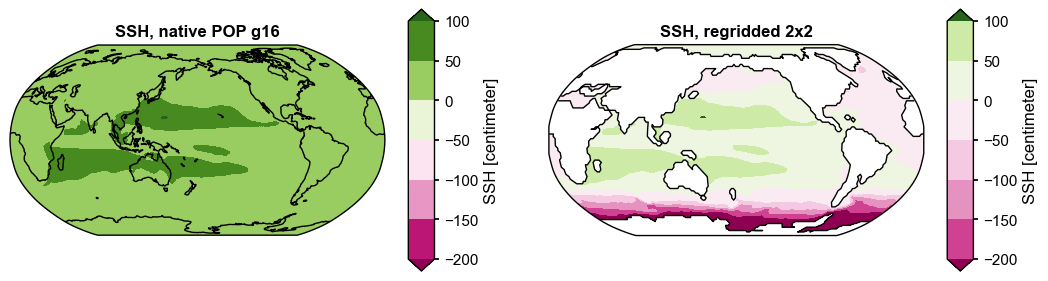

In [3]:
ax_loc = {'a': (0, 0), 'b': (0, 1)}
projs = {k: 'Robinson' for k in ax_loc}
projs_kws = {k: {'central_longitude': 180} for k in ax_loc}
fig, axd = x4c.subplots(1, 2, ax_loc=ax_loc, projs=projs, projs_kws=projs_kws,
                        figsize=(13, 3.4), wspace=0.15)

ds_ocn.x.da.isel(time=0).x.plot(ax=axd['a'], title='SSH, native POP g16')
ds_ocn_rgd.x.da.isel(time=0).x.plot(ax=axd['b'], title='SSH, regridded 2x2')
x4c.showfig(fig)